In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
data_dir = "/content/drive/MyDrive/NIKE_vs_ADIDAS-master"

In [5]:
import os
print(os.listdir("/content/drive/MyDrive/NIKE_vs_ADIDAS-master"))

['README.md', 'NIKE_ADIDAS_Classifier.ipynb', 'TEST', 'TRAIN']


In [7]:
import os

print("TRAIN level:", os.listdir(train_dir))

TRAIN level: ['ADIDAS_13.png', 'ADIDAS_10.png', 'ADIDAS_12.png', 'ADIDAS_11.png', 'ADIDAS_1.png', 'ADIDAS_44.png', 'NIKE_23.png', 'ADIDAS_7.png', 'ADIDAS_2.png', 'ADIDAS_50.png', 'NIKE_21.png', 'ADIDAS_41.png', 'ADIDAS_35.png', 'NIKE_26.png', 'ADIDAS_49.png', 'ADIDAS_15.png', 'NIKE_14.png', 'ADIDAS_3.png', 'NIKE_29.png', 'ADIDAS_34.png', 'ADIDAS_22.png', 'ADIDAS_16.png', 'NIKE_13.png', 'NIKE_28.png', 'NIKE_12.png', 'NIKE_22.png', 'ADIDAS_9.png', 'NIKE_10.png', 'ADIDAS_17.png', 'ADIDAS_14.png', 'NIKE_24.png', 'ADIDAS_27.png', 'NIKE_19.png', 'ADIDAS_33.png', 'ADIDAS_42.png', 'ADIDAS_23.png', 'ADIDAS_47.png', 'NIKE_16.png', 'NIKE_3.png', 'NIKE_2.png', 'ADIDAS_28.png', 'ADIDAS_25.png', 'ADIDAS_30.png', 'ADIDAS_45.png', 'ADIDAS_29.png', 'ADIDAS_20.png', 'ADIDAS_19.png', 'ADIDAS_6.png', 'NIKE_11.png', 'ADIDAS_48.png', 'NIKE_25.png', 'NIKE_27.png', 'ADIDAS_21.png', 'ADIDAS_18.png', 'ADIDAS_24.png', 'ADIDAS_37.png', 'ADIDAS_36.png', 'NIKE_20.png', 'ADIDAS_38.png', 'ADIDAS_43.png', 'NIKE_17.png

In [8]:
import os
import shutil

train_dir = "/content/drive/MyDrive/NIKE_vs_ADIDAS-master/TRAIN"

# Create class folders
os.makedirs(train_dir + "/adidas", exist_ok=True)
os.makedirs(train_dir + "/nike", exist_ok=True)

# Move files based on filename
for file in os.listdir(train_dir):
    if file.endswith(".png") or file.endswith(".jpg"):
        if "ADIDAS" in file.upper():
            shutil.move(train_dir + "/" + file, train_dir + "/adidas/" + file)
        elif "NIKE" in file.upper():
            shutil.move(train_dir + "/" + file, train_dir + "/nike/" + file)

print("Dataset fixed")

Dataset fixed


In [9]:
test_dir = "/content/drive/MyDrive/NIKE_vs_ADIDAS-master/TEST"

os.makedirs(test_dir + "/adidas", exist_ok=True)
os.makedirs(test_dir + "/nike", exist_ok=True)

for file in os.listdir(test_dir):
    if file.endswith(".png") or file.endswith(".jpg"):
        if "ADIDAS" in file.upper():
            shutil.move(test_dir + "/" + file, test_dir + "/adidas/" + file)
        elif "NIKE" in file.upper():
            shutil.move(test_dir + "/" + file, test_dir + "/nike/" + file)

print("Test dataset fixed")

Test dataset fixed


In [10]:
train_dir = data_dir + "/TRAIN"
test_dir  = data_dir + "/TEST"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 100 files belonging to 2 classes.
Found 40 files belonging to 2 classes.
['adidas', 'nike']


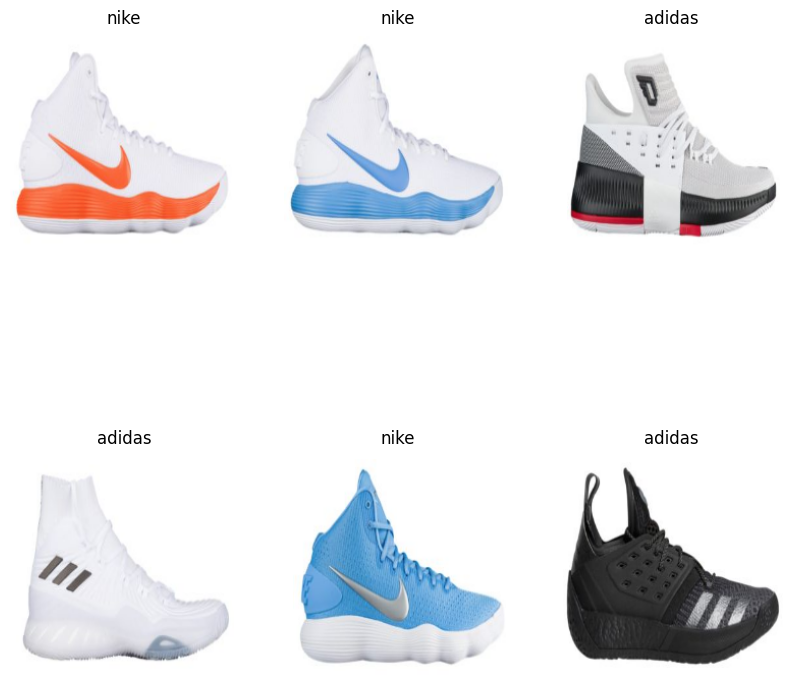

In [11]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7800 - loss: 0.3876 - val_accuracy: 0.7750 - val_loss: 0.4411
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9100 - loss: 0.2928 - val_accuracy: 0.7000 - val_loss: 0.5768
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9100 - loss: 0.1748 - val_accuracy: 0.8250 - val_loss: 0.4525
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9900 - loss: 0.1079 - val_accuracy: 0.6250 - val_loss: 1.8482
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9000 - loss: 0.2382 - val_accuracy: 0.8000 - val_loss: 0.4365
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9200 - loss: 0.1850 - val_accuracy: 0.6000 - val_loss: 0.9937
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8800 - loss: 0.2707 - val_accuracy: 0.8250 - val_loss: 0.4655
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.9900 - loss: 0.1474 - val_accuracy: 0.8250 - val_loss: 0.4355
Epoch 9/

### Test the model with a sample image

In [27]:
img_path = '/content/drive/MyDrive/NIKE_vs_ADIDAS-master/TEST/nike/NIKE_60.png' # Changed to an existing Nike image from the directory listing

IMG_SIZE = 224 # Ensure this matches the input size used for training

img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

# Normalize the image data (important as the model was trained on normalized data)
img_array = normalization_layer(img_array)

In [23]:
print(os.listdir(test_dir + "/adidas"))

['ADIDAS_63.png', 'ADIDAS_53.png', 'ADIDAS_69.png', 'ADIDAS_52.png', 'ADIDAS_54.png', 'ADIDAS_65.png', 'ADIDAS_60.png', 'ADIDAS_66.png', 'ADIDAS_55.png', 'ADIDAS_51.png', 'ADIDAS_57.png', 'ADIDAS_62.png', 'ADIDAS_67.png', 'ADIDAS_56.png', 'ADIDAS_70.png', 'ADIDAS_68.png', 'ADIDAS_61.png', 'ADIDAS_64.png', 'ADIDAS_59.png', 'ADIDAS_58.png']


In [26]:
print(os.listdir(test_dir + "/nike"))

['NIKE_60.png', 'NIKE_52.png', 'NIKE_55.png', 'NIKE_53.png', 'NIKE_54.png', 'NIKE_67.png', 'NIKE_59.png', 'NIKE_57.png', 'NIKE_51.png', 'NIKE_65.png', 'NIKE_63.png', 'NIKE_58.png', 'NIKE_66.png', 'NIKE_62.png', 'NIKE_61.png', 'NIKE_64.png', 'NIKE_69.png', 'NIKE_70.png', 'NIKE_68.png', 'NIKE_56.png']


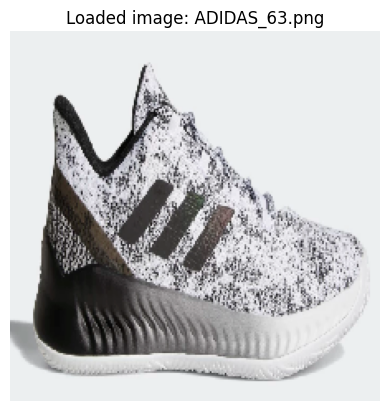

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Select an existing image path from the test directory
# Example: Using an Adidas image from the TEST/adidas folder
new_img_path = os.path.join(test_dir, 'adidas', 'ADIDAS_63.png')

# Load and preprocess the image
# Use tf.keras.utils.load_img to load the image and resize it
img = tf.keras.utils.load_img(new_img_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array = normalization_layer(img_array) # Normalize the image, consistent with model training

# Display the image
plt.imshow(img) # Display the original (un-normalized) image for better visual
plt.title(f"Loaded image: {os.path.basename(new_img_path)}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
This image most likely belongs to adidas with a 73.11% confidence.


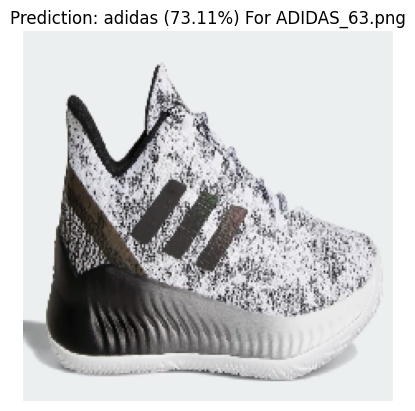

In [36]:
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

predicted_class_index = np.argmax(score)
predicted_class_name = class_names[predicted_class_index]
confidence = 100 * np.max(score)

print(f"This image most likely belongs to {predicted_class_name} with a {confidence:.2f}% confidence.")

plt.imshow(img)
plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}%) For {os.path.basename(new_img_path)}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
This image most likely belongs to nike with a 73.01% confidence.


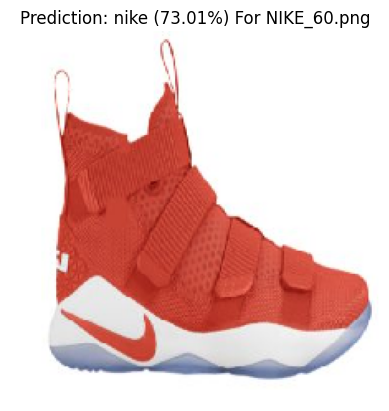

In [37]:
import os

# Select an existing Nike image path from the test directory
new_img_path_nike = os.path.join(test_dir, 'nike', 'NIKE_60.png')

# Load and preprocess the image
img_nike = tf.keras.utils.load_img(new_img_path_nike, target_size=(IMG_SIZE, IMG_SIZE))
img_array_nike = tf.keras.utils.img_to_array(img_nike)
img_array_nike = tf.expand_dims(img_array_nike, 0) # Create a batch
img_array_nike = normalization_layer(img_array_nike) # Normalize the image

# Make prediction
predictions_nike = model.predict(img_array_nike)
score_nike = tf.nn.softmax(predictions_nike[0])

predicted_class_index_nike = np.argmax(score_nike)
predicted_class_name_nike = class_names[predicted_class_index_nike]
confidence_nike = 100 * np.max(score_nike)

print(f"This image most likely belongs to {predicted_class_name_nike} with a {confidence_nike:.2f}% confidence.")

plt.imshow(img_nike)
plt.title(f"Prediction: {predicted_class_name_nike} ({confidence_nike:.2f}%) For {os.path.basename(new_img_path_nike)}")
plt.axis('off')
plt.show()